In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split


# Defining Forward kinematis using POE

In [ ]:
import numpy as np


def skew3(w):
    """
    Input:  3-vector w (angular part of screw axis)
    Output: 3x3 skew-symmetric matrix
    """
    w = w.flatten()
    return np.array([
        [ 0,    -w[2],  w[1]],
        [ w[2],  0,    -w[0]],
        [-w[1],  w[0],  0   ]
    ])


def vec_to_se3(S):
    """
    Convert a 6-vector screw axis S = [w; v] into a 4x4 se(3) matrix:
        [ [w]  v ]
        [  0   0 ]
    """
    S = S.flatten()
    omega = S[0:3]
    v     = S[3:6]
    se3 = np.zeros((4, 4))
    se3[0:3, 0:3] = skew3(omega)
    se3[0:3, 3]   = v
    return se3


def se3_to_SE3(S, theta):
    """
    Exponential map: given a 6-vector screw axis S and angle theta,
    return the 4x4 rigid body transform T in SE(3).

    Uses Rodrigues-style closed form (only valid for revolute joints, w != 0).
    """
    se3  = vec_to_se3(S)
    W    = se3[0:3, 0:3]   # skew-symmetric omega
    v    = se3[0:3, 3]     # linear velocity part

    R = (np.eye(3)
         + np.sin(theta) * W
         + (1 - np.cos(theta)) * (W @ W))

    G = (np.eye(3) * theta
         + (1 - np.cos(theta)) * W
         + (theta - np.sin(theta)) * (W @ W))

    p = G @ v

    T = np.eye(4)
    T[0:3, 0:3] = R
    T[0:3, 3]   = p
    return T


# --- Robot parameters (ViperX-300 6DOF) ---
# Source: https://docs.trossenrobotics.com/interbotix_xsarms_docs/specifications/vx300s.html
# Each ROW is the screw axis [w; v] for one joint, then transposed so
# each COLUMN is one joint — matches the doc's Slist^T convention.
Slist = np.array([
    [0,  0,  1,  0,        0,       0      ],  # joint 1 (waist)
    [0,  1,  0, -0.12705,  0,       0      ],  # joint 2 (shoulder)
    [0,  1,  0, -0.42705,  0,       0.05955],  # joint 3 (elbow)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 4 (forearm roll)
    [0,  1,  0, -0.42705,  0,       0.35955],  # joint 5 (wrist angle)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 6 (wrist rotate)
]).T  # shape: (6, 6) — column i is the screw axis for joint i

# End-effector home configuration (zero joint angles)
M_HOME = np.array([
    [1, 0, 0, 0.536494],
    [0, 1, 0, 0       ],
    [0, 0, 1, 0.42705 ],
    [0, 0, 0, 1       ]
], dtype=float)


def FK(q):
    """
    Forward kinematics via Product of Exponentials (space frame).

    Input:  q — list or array of 6 joint angles (radians)
    Output: 4x4 homogeneous transform T from base to end-effector
    """
    q = np.array(q).flatten()
    assert len(q) == 6, "Expected 6 joint angles"

    T = M_HOME.copy()
    for i in range(5, -1, -1):               # joints 5 → 0
        Ti = se3_to_SE3(Slist[:, i], q[i])
        T  = Ti @ T

    return T



# Generate DB

to do so pick points inside the configuarion space then add some random  delta to it . calculate the FK of both
save the original joint q the destinatoin x_d and the delta q .
This essentialy will allow to learn the local jacobian

In [ ]:

JOINT_LIMITS = np.deg2rad([
    [-180,  180],   # waist
    [-101,  101],   # shoulder
    [-101,   92],   # elbow
    [-180,  180],   # forearm roll
    [-107,  130],   # wrist angle
    [-180,  180],   # wrist rotate
])  # shape (6, 2)


def sample_q(n):
    """
    Sample n joint configurations uniformly within joint limits.
    Returns array of shape (n, 6).
    """
    lo = JOINT_LIMITS[:, 0]   # (6,)
    hi = JOINT_LIMITS[:, 1]   # (6,)
    return lo + np.random.rand(n, 6) * (hi - lo)


def perturb_q(q, delta=0.05, n_neighbours=5):
    """
    Given a joint config q (6,), generate n_neighbours nearby configs
    by adding small uniform noise in [-delta, +delta] per joint,
    clamped to joint limits.

    delta: max perturbation per joint in radians (~2.8 deg at 0.05)
    """
    lo = JOINT_LIMITS[:, 0]
    hi = JOINT_LIMITS[:, 1]

    noise = (np.random.rand(n_neighbours, 6) * 2 - 1) * delta  # uniform in [-delta, delta]
    q_neighbours = np.clip(q + noise, lo, hi)
    return q_neighbours


def generate_dataset(n_base=50_000, n_neighbours=5, delta=0.05):
    """
    Generate dataset of (q1, x_d, dq) tuples.

    For each base config q1:
      - sample n_neighbours nearby configs q2
      - compute x_d = FK(q2)[0:3, 3]
      - label = dq = q2 - q1

    Returns:
      q1_all  : (N, 6)  current joint config
      xd_all  : (N, 3)  target end-effector position
      dq_all  : (N, 6)  joint delta to apply
    where N = n_base * n_neighbours
    """
    N = n_base * n_neighbours
    q1_all = np.zeros((N, 6))
    xd_all = np.zeros((N, 3))
    dq_all = np.zeros((N, 6))

    base_configs = sample_q(n_base)

    idx = 0
    for i, q1 in enumerate(base_configs):
        if i % 5000 == 0:
            print(f"  generating... {i}/{n_base}")

        neighbours = perturb_q(q1, delta=delta, n_neighbours=n_neighbours)

        for q2 in neighbours:
            T2      = FK(q2)
            x_d     = T2[0:3, 3]
            dq      = q2 - q1

            q1_all[idx] = q1
            xd_all[idx] = x_d
            dq_all[idx] = dq
            idx += 1

    return q1_all, xd_all, dq_all


def validate_dataset(q1_all, xd_all, dq_all, n_check=1000):
    """
    Spot-check: for random samples, verify that FK(q1 + dq) ≈ x_d.
    Prints mean and max position error.
    """
    indices = np.random.choice(len(q1_all), n_check, replace=False)
    errors  = []

    for i in indices:
        q_reconstructed = q1_all[i] + dq_all[i]
        x_reconstructed = FK(q_reconstructed)[0:3, 3]
        err = np.linalg.norm(x_reconstructed - xd_all[i])
        errors.append(err)

    errors = np.array(errors)
    print(f"\nDataset validation ({n_check} samples):")
    print(f"  mean position error: {errors.mean():.32f} m")
    print(f"  max  position error: {errors.max():.32f}  m")
    print(f"  (should be ~0 — any error is a bug in FK or data gen)")


if __name__ == "__main__":
    np.random.seed(42)

    print("Generating dataset...")
    q1_all, xd_all, dq_all = generate_dataset(
        n_base=50_000,
        n_neighbours=5,
        delta=0.05       # ~2.8 degrees max perturbation per joint
    )

    print(f"\nDataset size: {len(q1_all):,} samples")
    print(f"  q1  shape: {q1_all.shape}")
    print(f"  x_d shape: {xd_all.shape}")
    print(f"  dq  shape: {dq_all.shape}")

    validate_dataset(q1_all, xd_all, dq_all)

    # save
    np.save("/content/drive/MyDrive/inverse_kinematics/q1.npy",  q1_all)
    np.save("/content/drive/MyDrive/inverse_kinematics/xd.npy",  xd_all)
    np.save("/content/drive/MyDrive/inverse_kinematics/dq.npy",  dq_all)
    print("\nSaved: q1.npy, xd.npy, dq.npy")

Generating dataset...
  generating... 0/50000
  generating... 5000/50000
  generating... 10000/50000
  generating... 15000/50000
  generating... 20000/50000
  generating... 25000/50000
  generating... 30000/50000
  generating... 35000/50000
  generating... 40000/50000
  generating... 45000/50000

Dataset size: 250,000 samples
  q1  shape: (250000, 6)
  x_d shape: (250000, 3)
  dq  shape: (250000, 6)

Dataset validation (1000 samples):
  mean position error: 0.00000000000000000000000000000000 m
  max  position error: 0.00000000000000000000000000000000  m
  (should be ~0 — any error is a bug in FK or data gen)

Saved: q1.npy, xd.npy, dq.npy


In [ ]:
# read data from drive
q1=np.load("/content/drive/MyDrive/inverse_kinematics/q1.npy")
xd=np.load("/content/drive/MyDrive/inverse_kinematics/xd.npy")
dq=np.load("/content/drive/MyDrive/inverse_kinematics/dq.npy")


# split to train,val,test
and save to drive  decided with 80,10,10 as i have enoguh data

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

SAVE_DIR = '/content/drive/MyDrive/inverse_kinematics'

q1 = np.load('q1.npy')
xd = np.load('xd.npy')
dq = np.load('dq.npy')

indices = np.arange(len(q1))

idx_train, idx_temp = train_test_split(indices, test_size=0.20, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

splits = {'train': idx_train, 'val': idx_val, 'test': idx_test}

for split, idx in splits.items():
    np.save(f'{SAVE_DIR}/q1_{split}.npy',  q1[idx])
    np.save(f'{SAVE_DIR}/xd_{split}.npy',  xd[idx])
    np.save(f'{SAVE_DIR}/dq_{split}.npy',  dq[idx])
    print(f'{split:>5}: {len(idx):>7,} samples')

print(f'\ntotal: {len(q1):,}')

train: 200,000 samples
  val:  25,000 samples
 test:  25,000 samples

total: 250,000


# differentiable forward kinematics
because the cost funtion is ||FK-Xd|| FK must be differentiable for back propogation  meaning it can't be done in numpy so I redo it in pytorch

In [ ]:

# --- Differentiable FK in PyTorch ---
import torch
Slist = torch.tensor([
    [0,  0,  1,  0,        0,       0      ],
    [0,  1,  0, -0.12705,  0,       0      ],
    [0,  1,  0, -0.42705,  0,       0.05955],
    [1,  0,  0,  0,        0.42705, 0      ],
    [0,  1,  0, -0.42705,  0,       0.35955],
    [1,  0,  0,  0,        0.42705, 0      ],
], dtype=torch.float32).T  # (6, 6) — column i = screw axis for joint i

M_HOME = torch.tensor([
    [1, 0, 0, 0.536494],
    [0, 1, 0, 0       ],
    [0, 0, 1, 0.42705 ],
    [0, 0, 0, 1       ],
], dtype=torch.float32)


def skew3_batch(w):
    """w: (B, 3) -> (B, 3, 3) skew-symmetric matrices"""
    B = w.shape[0]
    S = torch.zeros(B, 3, 3, device=w.device)
    S[:, 0, 1] = -w[:, 2]
    S[:, 0, 2] =  w[:, 1]
    S[:, 1, 0] =  w[:, 2]
    S[:, 1, 2] = -w[:, 0]
    S[:, 2, 0] = -w[:, 1]
    S[:, 2, 1] =  w[:, 0]
    return S


def se3_to_SE3_batch(S, theta):
    """
    S:     (6,)  screw axis [w; v]
    theta: (B,)  joint angles
    returns T: (B, 4, 4)
    """
    B = theta.shape[0]
    w = S[:3]                          # (3,)
    v = S[3:]                          # (3,)

    w_exp = w.unsqueeze(0).expand(B, 3)   # (B, 3)
    W = skew3_batch(w_exp)                # (B, 3, 3)

    sin_t = torch.sin(theta).view(B, 1, 1)
    cos_t = torch.cos(theta).view(B, 1, 1)
    t     = theta.view(B, 1, 1)

    I = torch.eye(3, device=theta.device).unsqueeze(0)

    R = I + sin_t * W + (1 - cos_t) * (W @ W)

    G = I * t + (1 - cos_t) * W + (t - torch.sin(theta).view(B, 1, 1)) * (W @ W)

    v_exp = v.view(1, 3, 1).expand(B, 3, 1)
    p = (G @ v_exp).squeeze(-1)          # (B, 3)

    T = torch.eye(4, device=theta.device).unsqueeze(0).expand(B, 4, 4).clone()
    T[:, :3, :3] = R
    T[:, :3,  3] = p
    return T


def FK_batch(q):
    """
    q: (B, 6) joint angles
    returns position: (B, 3)
    """
    B = q.shape[0]
    dev = q.device
    Slist_d  = Slist.to(dev)
    M_HOME_d = M_HOME.to(dev)

    T = M_HOME_d.unsqueeze(0).expand(B, 4, 4).clone()

    for i in range(5, -1, -1):
        Ti = se3_to_SE3_batch(Slist_d[:, i], q[:, i])
        T  = Ti @ T

    return T[:, :3, 3]   # (B, 3)


# Class for loading dataset

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
class IKDataset(Dataset):
    def __init__(self, split, scaler_X=None, scaler_Y=None):
        q1 = np.load(f'{SAVE_DIR}/q1_{split}.npy').astype(np.float32)
        xd = np.load(f'{SAVE_DIR}/xd_{split}.npy').astype(np.float32)
        dq = np.load(f'{SAVE_DIR}/dq_{split}.npy').astype(np.float32)

        X_raw = torch.from_numpy(np.concatenate([q1, xd], axis=1))
        Y_raw = torch.from_numpy(dq)

        if scaler_X is None:
            X_mean = X_raw.mean(dim=0)
            X_std  = X_raw.std(dim=0)
            Y_mean = Y_raw.mean(dim=0)
            Y_std  = Y_raw.std(dim=0)
            self.scaler_X = [X_mean, X_std]
            self.scaler_Y = [Y_mean, Y_std]

        else:
            self.scaler_X = scaler_X
            self.scaler_Y = scaler_Y

        self.X  = (X_raw - self.scaler_X[0]) / self.scaler_X[1]
        self.Y  = (Y_raw - self.scaler_Y[0]) / self.scaler_Y[1]
        self.q1 = torch.from_numpy(q1)
        self.xd = torch.from_numpy(xd)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.q1[idx], self.xd[idx]

#  Defining The MLP
instead of using some loss function like mse i will use the error in the task space ||FK-xd|| this make much more sense as it is the physical error

In [ ]:


# --- Model ---

class MLP(nn.Module):
    def __init__(self, input_dim=9, hidden_dim=256, output_dim=6, n_layers=4):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            layers += [
                nn.Linear(in_dim, hidden_dim),

                nn.LeakyReLU()
            ]
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for X, Y, q1, xd in loader:
        X, q1, xd = X.to(DEVICE), q1.to(DEVICE), xd.to(DEVICE)
        Y_mean = train_ds.scaler_Y[0].to(DEVICE)
        Y_std  = train_ds.scaler_Y[1].to(DEVICE)
        optimizer.zero_grad()
        dq_pred = model(X) * Y_std + Y_mean
        #resecaling
        q_pred   = q1 + dq_pred
        #q_pred = q_min + (q_max - q_min) * torch.sigmoid(q1 + dq_pred)

        x_reached = FK_batch(q_pred)
        loss  = torch.mean(torch.norm(x_reached - xd, dim=1))



        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, Y, q1, xd in loader:
            X, q1, xd = X.to(DEVICE), q1.to(DEVICE), xd.to(DEVICE)
            Y_mean = train_ds.scaler_Y[0].to(DEVICE)
            Y_std  = train_ds.scaler_Y[1].to(DEVICE)

            dq_pred = model(X) * Y_std + Y_mean

            q_pred    = q1 + dq_pred
            #q_pred = q_min + (q_max - q_min) * torch.sigmoid(q1 + dq_pred)
            x_reached = FK_batch(q_pred)
            loss = torch.mean(torch.norm(x_reached - xd, dim=1))

            total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


#load data  and  model

In [ ]:


# --- Main ---

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
#load data from drive
SAVE_DIR = '/content/drive/MyDrive/inverse_kinematics'
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {DEVICE}')




train_ds = IKDataset('train')
val_ds   = IKDataset('val',  train_ds.scaler_X, train_ds.scaler_Y)



train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)
Y_mean = train_ds.scaler_Y[0].to(DEVICE)
Y_std  = train_ds.scaler_Y[1].to(DEVICE)
JOINT_LIMITS = np.deg2rad([
    [-180,  180],   # waist
    [-101,  101],   # shoulder
    [-101,   92],   # elbow
    [-180,  180],   # forearm roll
    [-107,  130],   # wrist angle
    [-180,  180],   # wrist rotate
])  # shape (6, 2)

#q_min      = torch.tensor(JOINT_LIMITS[:, 0], dtype=torch.float32).to(DEVICE)
#q_max      = torch.tensor(JOINT_LIMITS[:, 1], dtype=torch.float32).to(DEVICE)
# move scalers to device once



model     = MLP().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'train samples:    {len(train_ds):,}')
print(f'val samples:      {len(val_ds):,}')
print()




using device: cpu
model parameters: 201,478
train samples:    200,000
val samples:      25,000



In [ ]:
torch.cuda.is_available()
model.load_state_dict(torch.load(f'{SAVE_DIR}/mlp_taskspace_best.pt'),torch.device('cpu'))

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

# train model

In [ ]:

EPOCHS   = 200
best_val = float('inf')
no_improvement=0
no_improvement_limit=30

"""
model.load_state_dict(
    torch.load(f'{SAVE_DIR}/mlp_25326_4l256n_leakRelu.pt', map_location=DEVICE),
    strict=False
)
"""

#model.load_state_dict(torch.load(f'{SAVE_DIR}/mlp_25326_4l256n_leakyrelu_withoutBatch.pt',map_location=DEVICE))
for epoch in range(1, EPOCHS + 1):
    train_loss = train(model, train_loader, optimizer)
    val_loss   = evaluate(model, val_loader)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), f'{SAVE_DIR}/mlp_25326_4l256n_leakyrelu_withoutBatch.pt')
        no_improvement=0
    else:
      no_improvement+=1



    print(f'epoch {epoch:3d} | train: {train_loss*1000:.3f} mm | val: {val_loss*1000:.3f} mm | lr: {optimizer.param_groups[0]["lr"]:.2e}')



    if no_improvement==no_improvement_limit:
      break

print(f'\nbest val loss: {best_val*1000:.3f} mm')
print(f'model saved to {SAVE_DIR}/mlp_taskspace_best.pt')


epoch   1 | train: 18.685 mm | val: 15.971 mm | lr: 1.00e-03
epoch   2 | train: 15.349 mm | val: 14.648 mm | lr: 1.00e-03
epoch   3 | train: 14.260 mm | val: 13.733 mm | lr: 1.00e-03
epoch   4 | train: 13.638 mm | val: 13.551 mm | lr: 1.00e-03
epoch   5 | train: 12.810 mm | val: 12.345 mm | lr: 1.00e-03
epoch   6 | train: 12.107 mm | val: 12.017 mm | lr: 1.00e-03
epoch   7 | train: 11.602 mm | val: 11.406 mm | lr: 1.00e-03
epoch   8 | train: 11.058 mm | val: 10.853 mm | lr: 1.00e-03
epoch   9 | train: 10.617 mm | val: 10.569 mm | lr: 1.00e-03
epoch  10 | train: 10.384 mm | val: 10.372 mm | lr: 1.00e-03
epoch  11 | train: 10.090 mm | val: 10.022 mm | lr: 1.00e-03
epoch  12 | train: 9.738 mm | val: 9.980 mm | lr: 1.00e-03
epoch  13 | train: 9.552 mm | val: 9.559 mm | lr: 1.00e-03
epoch  14 | train: 9.293 mm | val: 9.710 mm | lr: 1.00e-03
epoch  15 | train: 9.135 mm | val: 9.674 mm | lr: 1.00e-03
epoch  16 | train: 8.938 mm | val: 8.897 mm | lr: 1.00e-03
epoch  17 | train: 8.735 mm | val:


#Iterative IK


In [ ]:
def iterative_ik(q,xd, threshold=2e-3, max_iter=20, alpha=0.5):
    Y_mean = train_ds.scaler_Y[0].to(DEVICE)
    Y_std  = train_ds.scaler_Y[1].to(DEVICE)
    X_mean = train_ds.scaler_X[0].to(DEVICE)
    X_std  = train_ds.scaler_X[1].to(DEVICE)

    q=q.to(DEVICE)
    xd=xd.to(DEVICE)
    error_history = []

    for i in range(max_iter):
        inp = torch.cat([q, xd]).unsqueeze(0)          # (1, 9) raw
        inp_scaled = (inp - X_mean) / X_std            # normalize

        with torch.no_grad():
            dq = model(inp_scaled) * Y_std + Y_mean    # (1, 6)

        q = q + alpha * dq.squeeze(0)                  # update

        x_reached = FK_batch(q.unsqueeze(0))           # (1, 3)
        error = torch.norm(xd - x_reached.squeeze(0)).item()
        error_history.append(error)

        if error < threshold:
            return q, error_history, True

    return q, error_history, False


<All keys matched successfully>

In [ ]:
errors=[]
model.load_state_dict(torch.load(f'{SAVE_DIR}/mlp_25326_4l256n_leakyrelu_withoutBatch.pt', map_location=DEVICE))
from tqdm import tqdm
for i in tqdm(range(2500)):
  q,err,converged=iterative_ik(val_ds.q1[i],val_ds.xd[i],max_iter=20,alpha=1)
  errors.append(np.min(err)*1000)
  #print( f' converged={converged} | final={np.min(err)*1000:.2f}mm | steps={len(err)}')


100%|██████████| 2500/2500 [01:27<00:00, 28.73it/s]


(array([ 417., 1286.,  480.,  179.,   74.,   35.,   13.,    9.,    5.,
           2.]),
 array([ 0.14174206,  1.58305106,  3.02436007,  4.46566908,  5.90697809,
         7.34828709,  8.7895961 , 10.23090511, 11.67221412, 13.11352312,
        14.55483213]),
 <BarContainer object of 10 artists>)

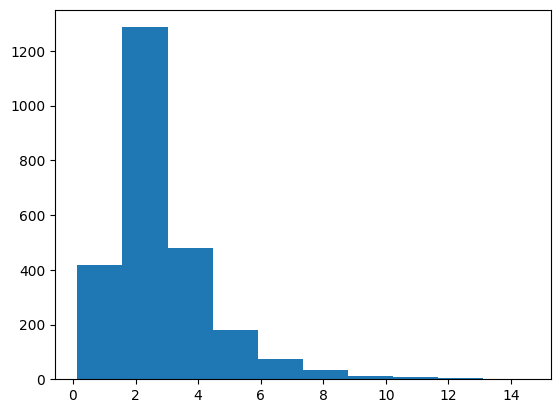

In [ ]:
plt.hist(errors)

In [ ]:
np.mean(errors)

np.float64(2.7984995127655568)

In [ ]:
for alpha in [0.1, 0.3, 0.5, 0.7, 1.0]:

  q, err_hist, converged = iterative_ik(val_ds.q1[5],val_ds.xd[5],max_iter=20, alpha=alpha)
  print(f'alpha={alpha} | converged={converged} | final={err_hist[-1]*1000:.2f}mm | steps={len(err_hist)}')
  print(f'  history: {[f"{e*1000:.1f}" for e in err_hist]}')

alpha=0.1 | converged=False | final=5.78mm | steps=20
  history: ['14.5', '13.6', '12.8', '12.0', '11.3', '10.7', '10.0', '9.5', '9.0', '8.5', '8.0', '7.6', '7.3', '7.0', '6.7', '6.4', '6.2', '6.1', '5.9', '5.8']
alpha=0.3 | converged=False | final=9.46mm | steps=20
  history: ['12.6', '10.4', '8.6', '7.3', '6.4', '5.8', '5.5', '5.4', '5.5', '5.8', '6.1', '6.5', '6.8', '7.2', '7.6', '8.0', '8.4', '8.8', '9.1', '9.5']
alpha=0.5 | converged=False | final=12.73mm | steps=20
  history: ['10.7', '7.7', '6.0', '5.3', '5.3', '5.8', '6.4', '7.1', '7.7', '8.4', '9.0', '9.6', '10.1', '10.5', '11.0', '11.4', '11.7', '12.1', '12.4', '12.7']
alpha=0.7 | converged=False | final=15.07mm | steps=20
  history: ['8.9', '5.8', '5.1', '5.6', '6.5', '7.5', '8.4', '9.2', '10.0', '10.6', '11.2', '11.7', '12.2', '12.6', '13.1', '13.5', '13.9', '14.3', '14.7', '15.1']
alpha=1.0 | converged=False | final=17.61mm | steps=20
  history: ['6.1', '4.8', '6.0', '7.4', '8.7', '9.8', '10.7', '11.5', '12.2', '12.8', '13

In [ ]:
max(err_hist)

0.029846392571926117

In [ ]:

best_result=[]
best_alpha_list=[]
for i in range(100) :
  best_approx=float('inf')
  best_alpha=0
  for alpha in [0.1, 0.3, 0.5, 0.7, 1.0]:
    q, err_hist, converged = iterative_ik(val_ds.q1[i],val_ds.xd[i],max_iter=20, alpha=alpha)
    if max(err_hist)<best_approx:
      best_approx=max(err_hist)
      best_alpha=alpha
  best_result.append(best_approx)
  best_alpha_list.append(best_alpha)







KeyboardInterrupt: 

# TESTING MODEL
TRYING TO UNDERSTAND THE RESULT I GOT

In [ ]:

#model.load_state_dict(torch.load(f'{SAVE_DIR}/mlp_taskspace_best.pt', map_location=DEVICE))

def evaluate_and_return_loss(model, loader):
    model.eval()
    all_losses = []
    with torch.no_grad():
        for X, Y, q1, xd in loader:
            X, q1, xd = X.to(DEVICE), q1.to(DEVICE), xd.to(DEVICE)
            Y_mean = train_ds.scaler_Y[0].to(DEVICE)
            Y_std  = train_ds.scaler_Y[1].to(DEVICE)
            dq_pred = model(X) * Y_std + Y_mean

            q_pred    = q1 + dq_pred
            x_reached = FK_batch(q_pred)
            loss = torch.norm(x_reached - xd, dim=1)
            all_losses.append(loss)

    return torch.cat(all_losses)




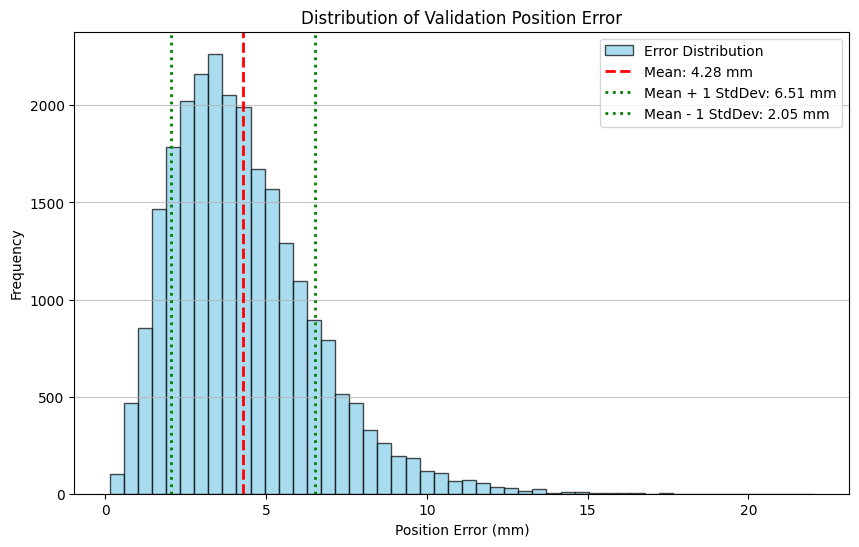

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
val_err = evaluate_and_return_loss(model, val_loader)
# Convert to millimeters for plotting
val_err_mm = val_err.cpu().numpy() * 1000

# Calculate mean and standard deviation
mean_err = np.mean(val_err_mm)
std_err = np.std(val_err_mm)

plt.figure(figsize=(10, 6))
plt.hist(val_err_mm, bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='Error Distribution')
plt.xlabel('Position Error (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Validation Position Error')

# Add lines for mean and 1 sigma
plt.axvline(mean_err, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_err:.2f} mm')
plt.axvline(mean_err + std_err, color='green', linestyle=':', linewidth=2, label=f'Mean + 1 StdDev: {mean_err + std_err:.2f} mm')
plt.axvline(mean_err - std_err, color='green', linestyle=':', linewidth=2, label=f'Mean - 1 StdDev: {mean_err - std_err:.2f} mm')

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

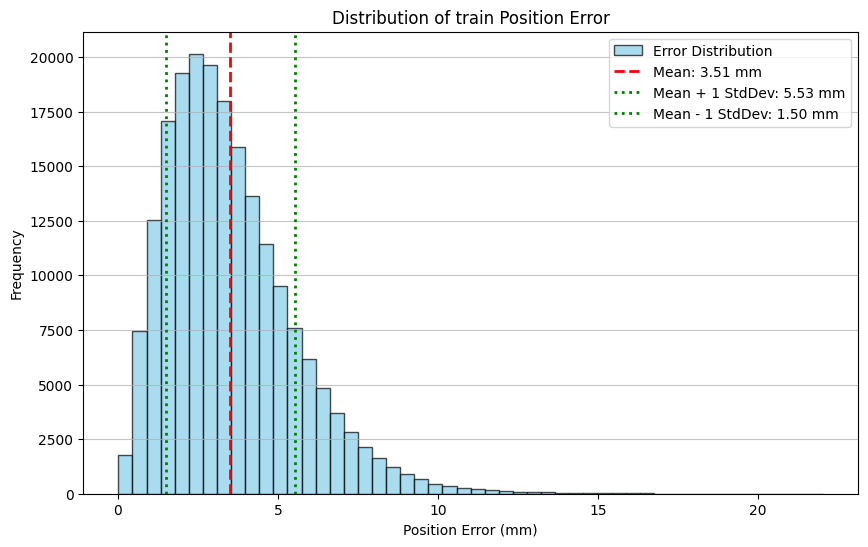

In [ ]:
# Convert to millimeters for plotting
train_err=evaluate_and_return_loss(model, train_loader)
train_err_mm = train_err.cpu().numpy()* 1000

# Calculate mean and standard deviation
mean_err = np.mean(train_err_mm)
std_err = np.std(train_err_mm)

plt.figure(figsize=(10, 6))
plt.hist(train_err_mm, bins=50, alpha=0.7, color='skyblue', edgecolor='black', label='Error Distribution')
plt.xlabel('Position Error (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of train Position Error')

# Add lines for mean and 1 sigma
plt.axvline(mean_err, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_err:.2f} mm')
plt.axvline(mean_err + std_err, color='green', linestyle=':', linewidth=2, label=f'Mean + 1 StdDev: {mean_err + std_err:.2f} mm')
plt.axvline(mean_err - std_err, color='green', linestyle=':', linewidth=2, label=f'Mean - 1 StdDev: {mean_err - std_err:.2f} mm')

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Diagnozing the errors

i want to check  few things
1.for data points that are on the edges of the task space the pertubation might birng them outside of it and this offcourse is a problem
2.we limited the nn to 2.8 deg perhaps its to large?
3. i  need to look at the 90% percentile and get some more insight

In [ ]:

sorted_val_error,idx=torch.sort(val_err, dim=-1, descending=False, stable=False)
sorted_val_error=sorted_val_error*1000;#turn to mm



In [ ]:
sample=idx[:].cpu()
dq_pred=model(val_ds.X[sample].unsqueeze(0).to(DEVICE)).detach().cpu()
dq_pred=dq_pred*val_ds.scaler_Y[1]+val_ds.scaler_Y[0]
q_pred=val_ds.q1[sample].unsqueeze(0)+dq_pred
q_pred=q_pred.squeeze(0)
x_reached=FK_batch(q_pred)
dq_pred


tensor([[[-0.0147,  0.0249,  0.0475, -0.0311, -0.0129, -0.0076],
         [-0.0197, -0.0810,  0.0236, -0.0771, -0.0093, -0.0010],
         [ 0.0170,  0.0258,  0.0070, -0.0149,  0.0135, -0.0083],
         ...,
         [ 0.0005, -0.0588, -0.0042, -0.0277, -0.0280, -0.0124],
         [-0.0135, -0.0254, -0.0314,  0.0855, -0.0019, -0.0152],
         [-0.0082,  0.0265,  0.0048, -0.0052,  0.0079, -0.0119]]])

In [ ]:
qd=dq_pred.squeeze(0)[sample]*val_ds.scaler_Y[1]+val_ds.scaler_Y[0]+val_ds.q1[sample].unsqueeze(0)
qd=qd.numpy().reshape(25000,6)
df=pd.DataFrame(qd)
df = df.apply(np.degrees, numeric_only=True)


the model can predict values outside of the joint space it must be adressed


In [ ]:
df.describe()


JOINT_LIMITS = np.deg2rad([
    [-180,  180],   # waist
    [-101,  101],   # shoulder
    [-101,   92],   # elbow
    [-180,  180],   # forearm roll
    [-107,  130],   # wrist angle
    [-180,  180],   # wrist rotate
])  # shape (6, 2)


tensor([[ 3.0790,  1.2664,  0.2410, -2.7878,  1.5601,  1.5778],
        [-2.8851, -0.9225, -1.6406, -0.0953, -1.2896,  2.3199],
        [ 0.9634, -1.7572, -1.7018,  1.9752,  1.1623,  0.2146],
        [-0.9372, -1.5339, -1.7734, -2.3507,  2.0025,  0.1459]])

In [ ]:
df.describe()


,0,1,2,3,4,5
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.172660,0.078128,-4.314463,1.007691,11.485080,0.047473
std,103.734413,58.238377,55.798271,103.228706,68.570930,104.106056
min,-180.070496,-101.038788,-101.005524,-180.174500,-107.044983,-180.008301
25%,-88.329655,-50.611878,-52.987328,-87.099743,-48.099706,-90.073938
50%,2.212714,0.437109,-4.148093,0.485869,11.793075,0.087173
75%,90.734735,50.183915,44.109806,89.553188,71.114365,90.729109
max,180.079620,101.036713,92.032227,180.007782,130.005569,179.998276


In [ ]:
# Calculate the 90th percentile of the unsorted validation errors
percentile_90_val_err = torch.quantile(val_err, 0.90)

# Get the number of samples corresponding to the top 10% of errors
num_worst_samples = int(0.10 * len(val_err))

# Get the indices from the original val_err that correspond to the top 10% errors
# Since `idx` contains the sorted indices (ascending), the worst errors are at the end.
worst_error_indices = idx[-num_worst_samples:].cpu()

# Retrieve the xd positions for these worst error samples
xd_worst_errors = val_ds.xd[worst_error_indices]

print(f"90th percentile error threshold: {percentile_90_val_err.item()*1000:.2f} mm")
print(f"Number of samples in the top 10% error: {len(worst_error_indices)}")
print(f"Shape of xd for worst errors: {xd_worst_errors.shape}")


90th percentile error threshold: 10.24 mm
Number of samples in the top 10% error: 2500
Shape of xd for worst errors: torch.Size([2500, 3])


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    x=xd_worst_errors[:, 0].cpu().numpy(),
    y=xd_worst_errors[:, 1].cpu().numpy(),
    z=xd_worst_errors[:, 2].cpu().numpy(),
    title='Interactive 3D Plot of Target Positions (xd) for Top 10% Errors',
    labels={
        'x': 'X Position (m)',
        'y': 'Y Position (m)',
        'z': 'Z Position (m)'
    }
)

fig.update_layout(scene_aspectmode='data') # Ensures equal scaling for axes
fig.show()

tensor([[  -9.2412,  139.2470,  -24.5400],
        [  -5.8197, -123.2535,  800.8395],
        [-285.2602,  108.7558,  629.0101],
        ...,
        [  -5.5012,   75.6720,  338.4468],
        [ -31.2534,  456.8590,   -2.7082],
        [-344.6815, -150.1178,  742.2283]])

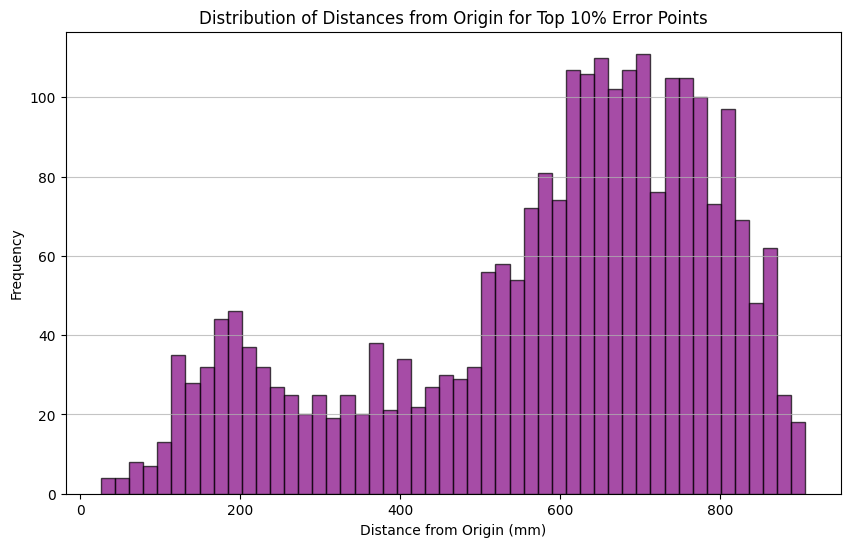

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the Euclidean distance from the origin for each point
distances_from_origin = torch.linalg.norm(xd_worst_errors, dim=1).cpu().numpy()

# Convert to millimeters for better interpretation if desired, though m is fine for distance
distances_from_origin_mm = distances_from_origin * 1000

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_from_origin_mm, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Distance from Origin (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances from Origin for Top 10% Error Points')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
q_pred = (val_ds.q1 + dq_pred).numpy().squeeze()
q_pred.reshape(25000,6)
violations = ((q_pred < JOINT_LIMITS[:, 0]) | (q_pred > JOINT_LIMITS[:, 1]))

print(f'joint limit violations: {violations.sum().item()} / {len(q_pred)}')

joint limit violations: 755 / 25000


In [ ]:
755/25000

0.0302

tensor([[[-0.0147,  0.0249,  0.0475, -0.0311, -0.0129, -0.0076],
         [-0.0197, -0.0810,  0.0236, -0.0771, -0.0093, -0.0010],
         [ 0.0170,  0.0258,  0.0070, -0.0149,  0.0135, -0.0083],
         ...,
         [ 0.0005, -0.0588, -0.0042, -0.0277, -0.0280, -0.0124],
         [-0.0135, -0.0254, -0.0314,  0.0855, -0.0019, -0.0152],
         [-0.0082,  0.0265,  0.0048, -0.0052,  0.0079, -0.0119]]])